# Regression and Classification: Error Analysis

**Course:** Introduction to Data Science  
**Assignment:** EX2 — Regression and Classification: Error Analysis  
**Dataset:** Data center energy consumption and weather sensor measurements  
**Student:** Itamar Perez  
**Student ID:** _fill in before submission_

This notebook adapts the data-center dataset from EX1 to the requirements of EX2.  
The analysis contains two predictive tasks:

1. **Regression:** predict `cooling_kw`, the cooling power demand.
2. **Classification:** predict `high_cooling_load`, a binary label that marks the top 25% of `cooling_kw` values.

The notebook focuses on systematic error analysis, not only model scores. It compares multiple models, studies residuals, examines extreme errors, analyzes false positives and false negatives, and evaluates threshold sensitivity.

## 1. Assignment Requirements Covered

This notebook covers the requested components:

- k-fold cross-validation for all modeling analyses.
- Justification of the selected value of `k`.
- Regression residual analysis.
- Residual distribution and heteroscedasticity inspection.
- Error as a function of features.
- Top 5% largest absolute regression errors.
- Regression metrics and statistical properties of residuals.
- Comparison of Linear Regression, Decision Tree Regressor, and Random Forest Regressor.
- Classification confusion matrix analysis.
- False Positive and False Negative analysis.
- Probability-based classification error analysis.
- Classification error as a function of features.
- Threshold sensitivity for thresholds 0.1 to 0.9.
- Precision, Recall, F1-score, Fβ-score, MCC, ROC-AUC, and ROC curve.
- Final reflection about where the models fail, why they fail, and how to improve them.

## 2. Dataset and Problem Formulation

The original EX1 notebook analyzed operational time-series measurements from a data center. The variables include power metrics such as IT power, cooling power, HVAC power, pump power and PUE, together with outside weather measurements.

For EX2, the same dataset is formulated as two supervised learning problems.

### Regression formulation

The regression target is:

\[
y = \texttt{cooling\_kw}
\]

The goal is to estimate the cooling demand from operational and environmental variables.

### Classification formulation

The classification target is created from the regression target:

\[
\texttt{high\_cooling\_load}=1
\quad\text{if}\quad
\texttt{cooling\_kw}\geq Q_{0.75}(\texttt{cooling\_kw})
\]

This makes the classification problem meaningful because `pue_category` from EX1 was almost entirely one category, while `high_cooling_load` creates a useful binary operational label.

In [1]:
# Core libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Modeling and evaluation
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_predict

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    matthews_corrcoef,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

## 3. Data Loading

The notebook supports two options:

1. Load a small processed file named `data_center_working_sample.csv` if it exists.
2. Otherwise, reconstruct the 1,500-row working dataset from the raw CSV files in `data/raw`, using the same logic as EX1.

For submission, it is recommended to include the small `data_center_working_sample.csv` file so the notebook can run without the very large raw files.

In [2]:
WORKING_SAMPLE_PATH = Path("data_center_working_sample.csv")
RAW_DATA_DIR = Path("data") / "raw"
SAMPLE_SIZE = 1500


def clean_timestamp_column(dataframe, timestamp_column="ts"):
    # Clean timestamp strings and convert them to UTC datetimes.
    cleaned_timestamp = (
        dataframe[timestamp_column]
        .astype("string")
        .str.replace(r"\s*\(.*?\)\s*$", "", regex=True)
    )

    return pd.to_datetime(
        cleaned_timestamp,
        errors="coerce",
        utc=True,
    )


def load_sample_from_raw(raw_data_dir=RAW_DATA_DIR, sample_size=SAMPLE_SIZE):
    # Recreate the EX1 working sample from raw power and weather CSV files.
    raw_csv_files = sorted(raw_data_dir.glob("*.csv"))

    if not raw_csv_files:
        raise FileNotFoundError(
            "No CSV files were found. Add data_center_working_sample.csv "
            "to the project root, or place the original raw CSV files in data/raw."
        )

    power_file_path = None
    weather_file_path = None

    for file_path in raw_csv_files:
        columns = pd.read_csv(file_path, nrows=0).columns.tolist()

        if "pue" in columns and "it_power_kw" in columns:
            power_file_path = file_path

        if "outdoor_air_temp" in columns and "outdoor_air_humidity" in columns:
            weather_file_path = file_path

    if power_file_path is None:
        raise FileNotFoundError("Power metrics CSV file was not found in data/raw.")

    if weather_file_path is None:
        raise FileNotFoundError("Weather CSV file was not found in data/raw.")

    power_columns_to_load = [
        "tags", "ts", "cooling_kw", "energy_reuse", "ere", "hvac_kw",
        "it_power_kw", "plug_and_light_kw", "pue", "pump_kw", "day"
    ]

    weather_columns_to_load = [
        "tags", "ts", "outdoor_air_humidity", "outdoor_air_temp", "unit", "day"
    ]

    minimum_valid_timestamp = pd.Timestamp("2016-06-12", tz="UTC")

    power_chunks = []
    target_power_rows = max(sample_size * 2, 3000)

    for chunk in pd.read_csv(
        power_file_path,
        usecols=power_columns_to_load,
        chunksize=100_000,
        low_memory=False,
    ):
        chunk["ts"] = clean_timestamp_column(chunk, "ts")
        chunk = chunk.dropna(subset=["ts", "cooling_kw", "it_power_kw", "pue"])
        chunk = chunk[chunk["ts"] >= minimum_valid_timestamp]
        power_chunks.append(chunk)

        if sum(len(part) for part in power_chunks) >= target_power_rows:
            break

    power_sample_df = pd.concat(power_chunks, ignore_index=True).head(target_power_rows)

    weather_chunks = []
    target_weather_rows = target_power_rows + 10

    for chunk in pd.read_csv(
        weather_file_path,
        usecols=weather_columns_to_load,
        chunksize=100_000,
        low_memory=False,
    ):
        chunk["ts"] = clean_timestamp_column(chunk, "ts")
        chunk = chunk.dropna(subset=["ts", "outdoor_air_temp", "outdoor_air_humidity"])
        chunk = chunk[chunk["ts"] >= minimum_valid_timestamp]
        weather_chunks.append(chunk)

        if sum(len(part) for part in weather_chunks) >= target_weather_rows:
            break

    weather_sample_df = pd.concat(weather_chunks, ignore_index=True).head(target_weather_rows)

    power_sample_df = power_sample_df.sort_values("ts").reset_index(drop=True)
    weather_sample_df = weather_sample_df.sort_values("ts").reset_index(drop=True)

    data_center_df = pd.merge_asof(
        power_sample_df,
        weather_sample_df,
        on="ts",
        direction="nearest",
        tolerance=pd.Timedelta("2min"),
        suffixes=("_power", "_weather"),
    )

    data_center_df = data_center_df.dropna(
        subset=["cooling_kw", "it_power_kw", "pue", "outdoor_air_temp", "outdoor_air_humidity"]
    )

    return data_center_df.head(sample_size).copy().reset_index(drop=True)


if WORKING_SAMPLE_PATH.exists():
    eda_df = pd.read_csv(WORKING_SAMPLE_PATH)
    if "ts" in eda_df.columns:
        eda_df["ts"] = pd.to_datetime(eda_df["ts"], errors="coerce", utc=True)
    print("Loaded working sample from:", WORKING_SAMPLE_PATH)
else:
    eda_df = load_sample_from_raw()
    eda_df.to_csv(WORKING_SAMPLE_PATH, index=False)
    print("Created working sample and saved it to:", WORKING_SAMPLE_PATH)

print("Shape:", eda_df.shape)
print("Columns:", eda_df.columns.tolist())
display(eda_df.head())

Loaded working sample from: data_center_working_sample.csv
Shape: (1500, 26)
Columns: ['tags_power', 'ts', 'cooling_kw', 'energy_reuse', 'ere', 'hvac_kw', 'it_power_kw', 'plug_and_light_kw', 'pue', 'pump_kw', 'day_power', 'tags_weather', 'outdoor_air_humidity', 'outdoor_air_temp', 'unit', 'day_weather', 'hour_of_day', 'minute_of_day', 'day_of_week', 'month', 'date', 'is_weekend', 'total_facility_kw', 'cooling_to_it_ratio', 'load_level', 'pue_category']


,tags_power,ts,cooling_kw,energy_reuse,ere,hvac_kw,it_power_kw,plug_and_light_kw,pue,pump_kw,day_power,tags_weather,outdoor_air_humidity,outdoor_air_temp,unit,day_weather,hour_of_day,minute_of_day,day_of_week,month,date,is_weekend,total_facility_kw,cooling_to_it_ratio,load_level,pue_category
0,NaN,2016-07-28 08:45:24+00:00,7.47,NaN,0.936,9.06,887.73,2.46,1.034,11.52,28,NaN,63.9,67.4,NaN,28,8,525,Thursday,7,2016-07-28,False,918.24,0.008415,Low,Excellent
1,NaN,2016-07-28 08:46:22+00:00,7.77,NaN,0.936,9.44,885.44,2.46,1.035,11.22,28,NaN,63.9,67.4,NaN,28,8,526,Thursday,7,2016-07-28,False,916.33,0.008775,Low,Excellent
2,NaN,2016-07-28 08:47:22+00:00,7.77,NaN,0.941,9.34,885.08,2.44,1.035,11.22,28,NaN,63.9,67.3,NaN,28,8,527,Thursday,7,2016-07-28,False,915.85,0.008779,Low,Excellent
3,NaN,2016-07-28 08:48:22+00:00,7.67,NaN,0.947,10.06,887.15,2.46,1.036,11.72,28,NaN,63.9,67.1,NaN,28,8,528,Thursday,7,2016-07-28,False,919.06,0.008646,Low,Excellent
4,NaN,2016-07-28 08:49:23+00:00,7.67,NaN,0.950,10.01,885.13,2.44,1.036,11.72,28,NaN,63.9,67.0,NaN,28,8,529,Thursday,7,2016-07-28,False,916.97,0.008665,Low,Excellent


## 4. Data Preparation

The same feature set is used across all regression models for a fair comparison.  
The same feature set is also used for all classification models.

The target `cooling_kw` is not included as an input feature, because it is the value we are trying to predict.

In [3]:
# Basic feature engineering
model_df = eda_df.copy()

if "ts" in model_df.columns:
    model_df["ts"] = pd.to_datetime(model_df["ts"], errors="coerce", utc=True)
    model_df["hour_of_day"] = model_df["ts"].dt.hour
    model_df["minute_of_day"] = model_df["ts"].dt.hour * 60 + model_df["ts"].dt.minute
else:
    model_df["hour_of_day"] = 0
    model_df["minute_of_day"] = 0

candidate_features = [
    "outdoor_air_temp",
    "outdoor_air_humidity",
    "it_power_kw",
    "hvac_kw",
    "pump_kw",
    "plug_and_light_kw",
    "hour_of_day",
    "minute_of_day",
]

REGRESSION_TARGET = "cooling_kw"

FEATURES = [
    feature for feature in candidate_features
    if feature in model_df.columns
]

required_columns = FEATURES + [REGRESSION_TARGET]
model_df = model_df[required_columns].copy()

# Convert to numeric and remove rows that cannot be used for modeling
for column in required_columns:
    model_df[column] = pd.to_numeric(model_df[column], errors="coerce")

model_df = model_df.dropna().drop_duplicates().reset_index(drop=True)

# Create binary classification target: top 25% cooling demand
cooling_threshold = model_df[REGRESSION_TARGET].quantile(0.75)
model_df["high_cooling_load"] = (
    model_df[REGRESSION_TARGET] >= cooling_threshold
).astype(int)

CLASSIFICATION_TARGET = "high_cooling_load"

print("Modeling dataset shape:", model_df.shape)
print("Regression target:", REGRESSION_TARGET)
print("Classification target:", CLASSIFICATION_TARGET)
print("Cooling threshold for high load:", round(cooling_threshold, 4))
print("Features:", FEATURES)
print()
print("Classification target distribution:")
display(model_df[CLASSIFICATION_TARGET].value_counts(normalize=True).rename("proportion"))

display(model_df.head())

Modeling dataset shape: (1500, 10)
Regression target: cooling_kw
Classification target: high_cooling_load
Cooling threshold for high load: 14.97
Features: ['outdoor_air_temp', 'outdoor_air_humidity', 'it_power_kw', 'hvac_kw', 'pump_kw', 'plug_and_light_kw', 'hour_of_day', 'minute_of_day']

Classification target distribution:


high_cooling_load
0    0.746667
1    0.253333
Name: proportion, dtype: float64

,outdoor_air_temp,outdoor_air_humidity,it_power_kw,hvac_kw,pump_kw,plug_and_light_kw,hour_of_day,minute_of_day,cooling_kw,high_cooling_load
0,67.4,63.9,887.73,9.06,11.52,2.46,8,525,7.47,0
1,67.4,63.9,885.44,9.44,11.22,2.46,8,526,7.77,0
2,67.3,63.9,885.08,9.34,11.22,2.44,8,527,7.77,0
3,67.1,63.9,887.15,10.06,11.72,2.46,8,528,7.67,0
4,67.0,63.9,885.13,10.01,11.72,2.44,8,529,7.67,0


In [4]:
# Export the compact modeling sample for reproducibility
model_df.to_csv("data_center_working_sample_ex2.csv", index=False)
print("Saved compact EX2 modeling sample: data_center_working_sample_ex2.csv")

Saved compact EX2 modeling sample: data_center_working_sample_ex2.csv


## 5. Choice of k for Cross-Validation

All model evaluations in this notebook use k-fold cross-validation.

I use:

\[
k=5
\]

Justification:

- The working dataset has about 1,500 rows, so each fold contains about 300 observations.
- Five folds provide a reasonable balance between stable evaluation and computational cost.
- A smaller `k`, such as 2 or 3, may create higher variance in the evaluation because each validation fold is larger and fewer validation estimates are averaged.
- A much larger `k`, such as 10, would require more model fits and would be computationally heavier, especially for ensemble models.
- For classification, `StratifiedKFold` is used to preserve the proportion of high and non-high cooling load cases in every fold.

In [5]:
K = 5

regression_cv = KFold(
    n_splits=K,
    shuffle=True,
    random_state=RANDOM_STATE,
)

classification_cv = StratifiedKFold(
    n_splits=K,
    shuffle=True,
    random_state=RANDOM_STATE,
)

X = model_df[FEATURES]
y_reg = model_df[REGRESSION_TARGET]
y_cls = model_df[CLASSIFICATION_TARGET]

print("Regression folds:", regression_cv)
print("Classification folds:", classification_cv)
print("Rows per fold approximately:", len(model_df) // K)

Regression folds: KFold(n_splits=5, random_state=42, shuffle=True)
Classification folds: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
Rows per fold approximately: 300


# Part A — Regression Error Analysis

## 6. Regression Models

The required regression models are:

1. **Linear Regression** — baseline linear model.
2. **Decision Tree Regressor** — non-linear tree-based model.
3. **Random Forest Regressor** — ensemble model that combines many decision trees.

All models use the same feature set.

In [6]:
regression_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

regression_models = {
    "Linear Regression": Pipeline(
        steps=[
            ("preprocess", regression_preprocessor),
            ("model", LinearRegression()),
        ]
    ),
    "Decision Tree Regressor": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", DecisionTreeRegressor(
                max_depth=6,
                min_samples_leaf=10,
                random_state=RANDOM_STATE,
            )),
        ]
    ),
    "Random Forest Regressor": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(
                n_estimators=250,
                min_samples_leaf=5,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )),
        ]
    ),
}

regression_predictions = {}
regression_metric_rows = []

for model_name, model in regression_models.items():
    y_pred = cross_val_predict(
        model,
        X,
        y_reg,
        cv=regression_cv,
        n_jobs=-1,
    )

    regression_predictions[model_name] = y_pred

    mae = mean_absolute_error(y_reg, y_pred)
    mse = mean_squared_error(y_reg, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_reg, y_pred)

    regression_metric_rows.append({
        "model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
    })

regression_results = pd.DataFrame(regression_metric_rows).sort_values("RMSE")
display(regression_results)

best_regression_model_name = regression_results.iloc[0]["model"]
best_regression_predictions = regression_predictions[best_regression_model_name]

print("Best regression model by RMSE:", best_regression_model_name)

,model,MAE,MSE,RMSE,R2
2,Random Forest Regressor,0.382418,0.296927,0.544910,0.983740
1,Decision Tree Regressor,0.671767,1.004082,1.002039,0.945015
0,Linear Regression,1.349775,3.016728,1.736873,0.834801


Best regression model by RMSE: Random Forest Regressor


### Regression Model Discussion

The table above compares the models using MAE, MSE, RMSE, and R².

- **Linear Regression** is the baseline. It is interpretable but may fail when the relationship between cooling demand and features is non-linear.
- **Decision Tree Regressor** can capture non-linear thresholds and interactions, but it can overfit if the tree is too deep.
- **Random Forest Regressor** reduces variance by averaging many trees. It is usually less interpretable than a single tree, but often provides stronger predictive performance.

The preferred regression model is selected according to cross-validated RMSE, because RMSE penalizes large errors strongly, which is important when analyzing operational cooling-load errors.

## 7. Residual Analysis

For each observation, the residual is defined as:

\[
\text{Residual}=y-\hat{y}
\]

Positive residual means the model under-predicted the true cooling load.  
Negative residual means the model over-predicted the true cooling load.

In [7]:
regression_error_df = X.copy()
regression_error_df["y_true"] = y_reg.values
regression_error_df["y_pred"] = best_regression_predictions
regression_error_df["residual"] = regression_error_df["y_true"] - regression_error_df["y_pred"]
regression_error_df["absolute_error"] = regression_error_df["residual"].abs()

residual_mean = regression_error_df["residual"].mean()
residual_std = regression_error_df["residual"].std()
abs_error_pred_corr = regression_error_df[["absolute_error", "y_pred"]].corr(method="spearman").iloc[0, 1]

print("Residual mean:", round(residual_mean, 4))
print("Residual standard deviation:", round(residual_std, 4))
print("Spearman correlation between absolute error and predicted value:", round(abs_error_pred_corr, 4))

display(regression_error_df.head())

Residual mean: 0.0071
Residual standard deviation: 0.545
Spearman correlation between absolute error and predicted value: 0.0156


,outdoor_air_temp,outdoor_air_humidity,it_power_kw,hvac_kw,pump_kw,plug_and_light_kw,hour_of_day,minute_of_day,y_true,y_pred,residual,absolute_error
0,67.4,63.9,887.73,9.06,11.52,2.46,8,525,7.47,7.415174,0.054826,0.054826
1,67.4,63.9,885.44,9.44,11.22,2.46,8,526,7.77,7.418238,0.351762,0.351762
2,67.3,63.9,885.08,9.34,11.22,2.44,8,527,7.77,7.420044,0.349956,0.349956
3,67.1,63.9,887.15,10.06,11.72,2.46,8,528,7.67,7.458629,0.211371,0.211371
4,67.0,63.9,885.13,10.01,11.72,2.44,8,529,7.67,7.406488,0.263512,0.263512


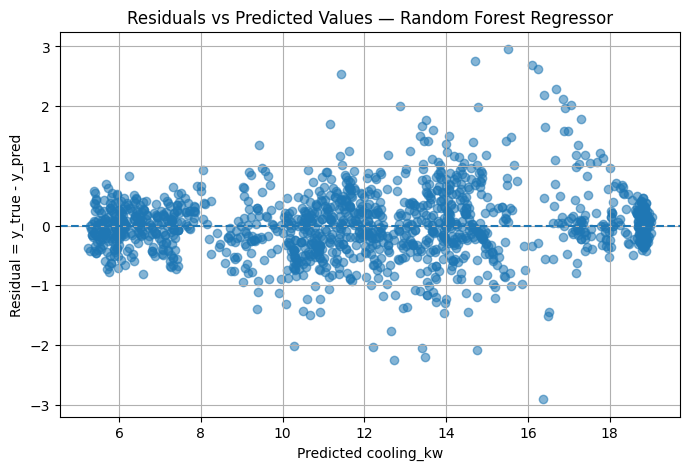

In [8]:
# Residuals as a function of predicted values
plt.figure(figsize=(8, 5))
plt.scatter(
    regression_error_df["y_pred"],
    regression_error_df["residual"],
    alpha=0.55,
)
plt.axhline(0, linestyle="--")
plt.title(f"Residuals vs Predicted Values — {best_regression_model_name}")
plt.xlabel("Predicted cooling_kw")
plt.ylabel("Residual = y_true - y_pred")
plt.show()

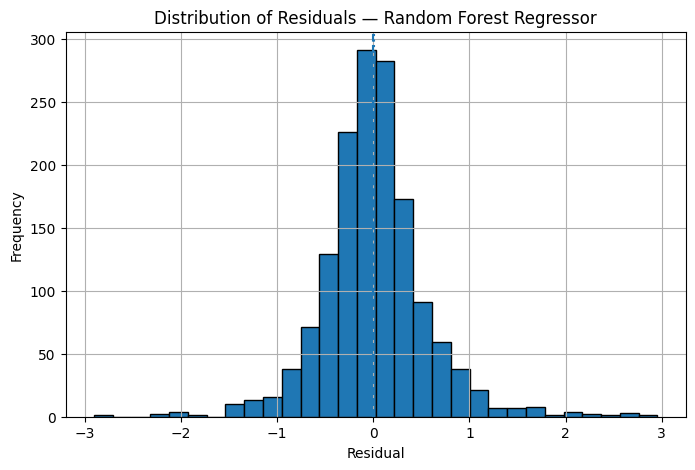

In [9]:
# Distribution of residuals
plt.figure(figsize=(8, 5))
plt.hist(regression_error_df["residual"], bins=30, edgecolor="black")
plt.axvline(0, linestyle="--")
plt.axvline(residual_mean, linestyle=":")
plt.title(f"Distribution of Residuals — {best_regression_model_name}")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

In [10]:
# Automatic residual interpretation
centered = abs(residual_mean) < 0.10 * residual_std
heteroscedasticity_signal = abs(abs_error_pred_corr) > 0.20

print("Residual interpretation:")
print("- Are residuals centered around zero?", "Yes" if centered else "Not perfectly")
print("- Evidence of heteroscedasticity?", "Possible" if heteroscedasticity_signal else "No strong evidence from this diagnostic")
print("- Interpretation:")

if centered:
    print("  The residual mean is small relative to the residual standard deviation, so the model does not show a strong global bias.")
else:
    print("  The residual mean is not negligible relative to the residual spread, which may indicate systematic over- or under-prediction.")

if heteroscedasticity_signal:
    print("  The absolute errors change with predicted values, suggesting that the error variance may not be constant across the prediction range.")
else:
    print("  The absolute errors do not show a strong monotonic relationship with predicted values in this simple diagnostic.")

Residual interpretation:
- Are residuals centered around zero? Yes
- Evidence of heteroscedasticity? No strong evidence from this diagnostic
- Interpretation:
  The residual mean is small relative to the residual standard deviation, so the model does not show a strong global bias.
  The absolute errors do not show a strong monotonic relationship with predicted values in this simple diagnostic.


## 8. Error as a Function of Features

This section plots feature values versus residuals and absolute errors.  
The goal is to identify non-linear relationships, feature-dependent error patterns, and hidden subpopulations where the model performs worse.

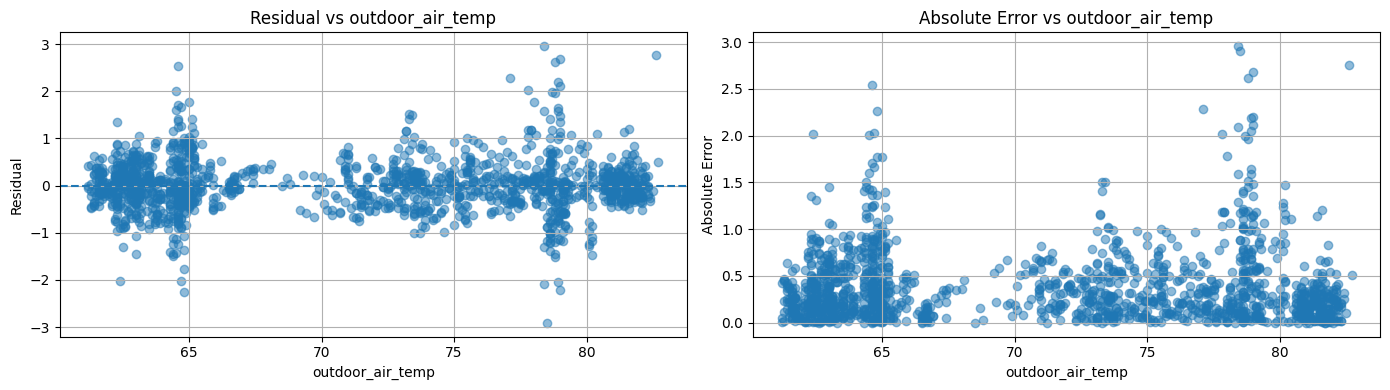

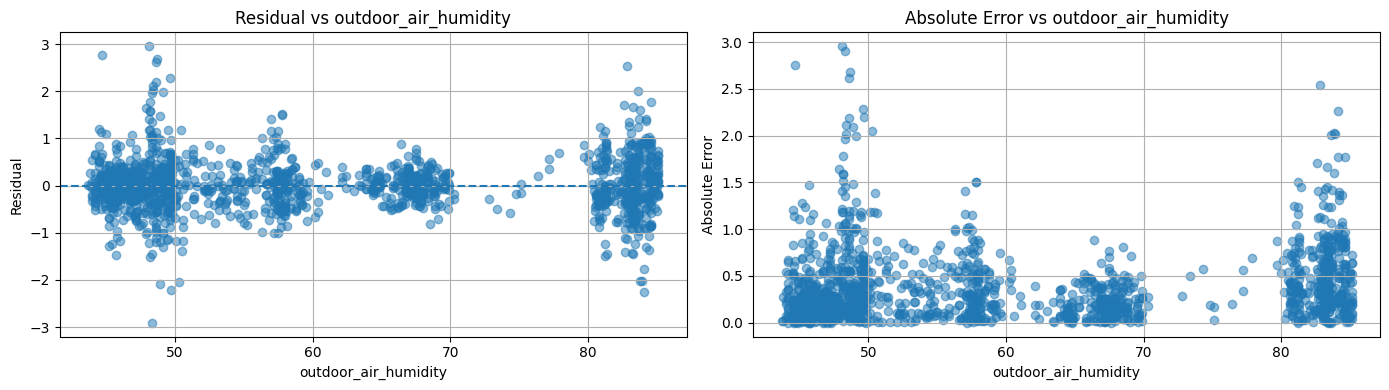

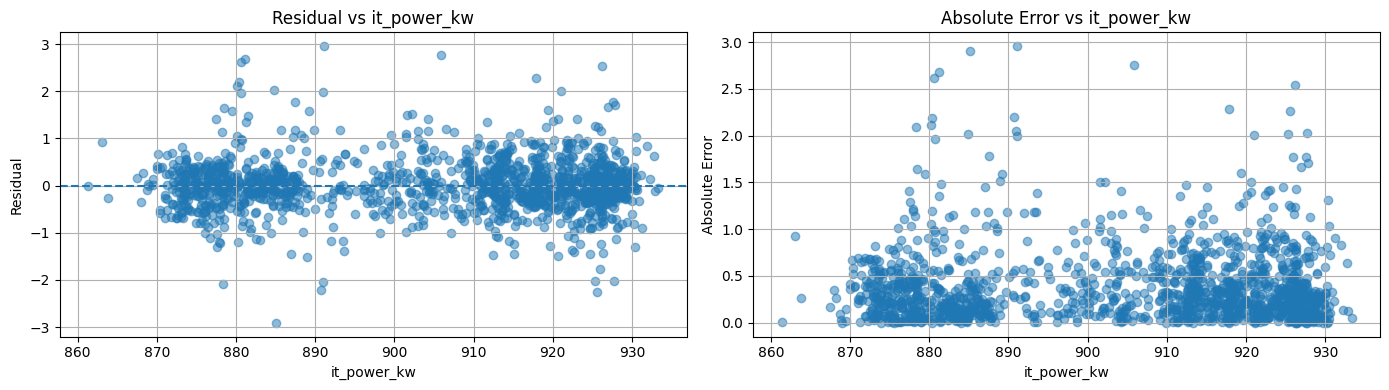

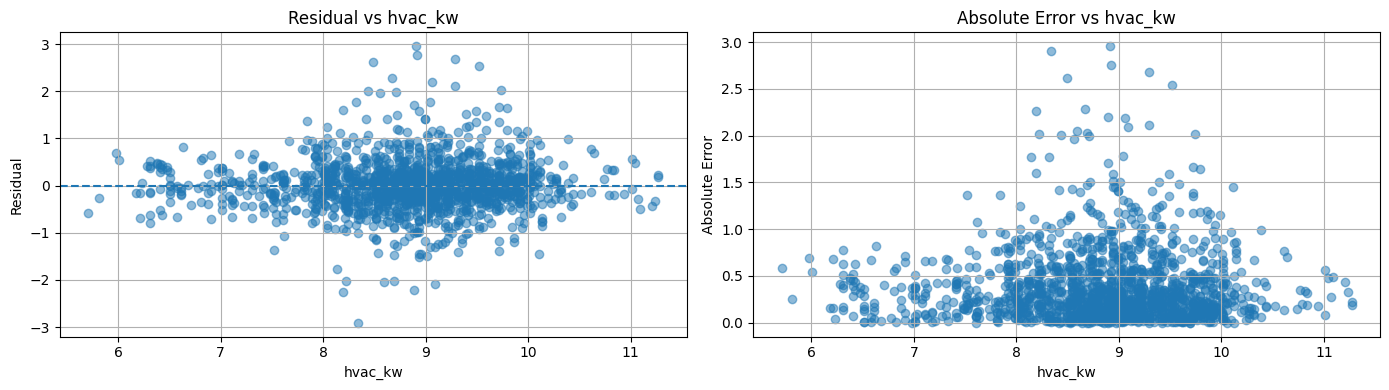

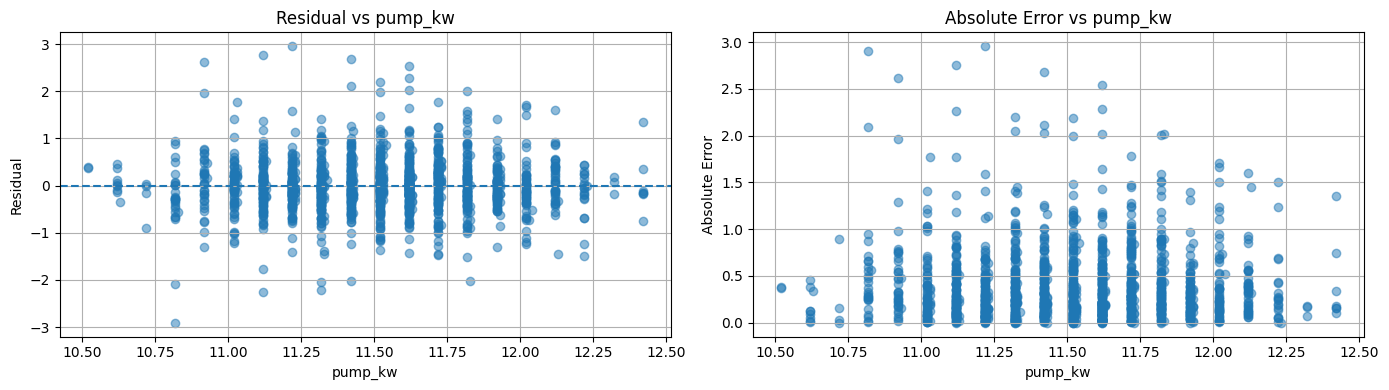

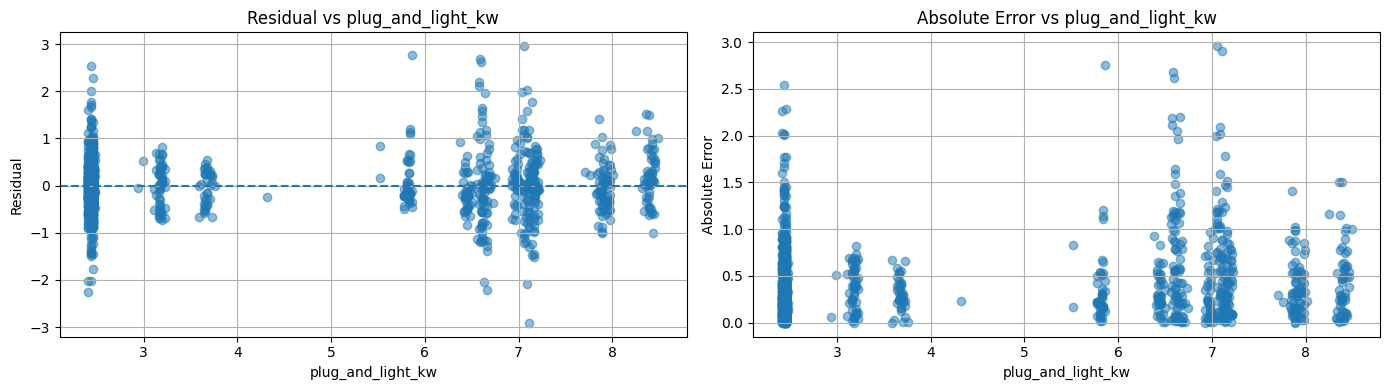

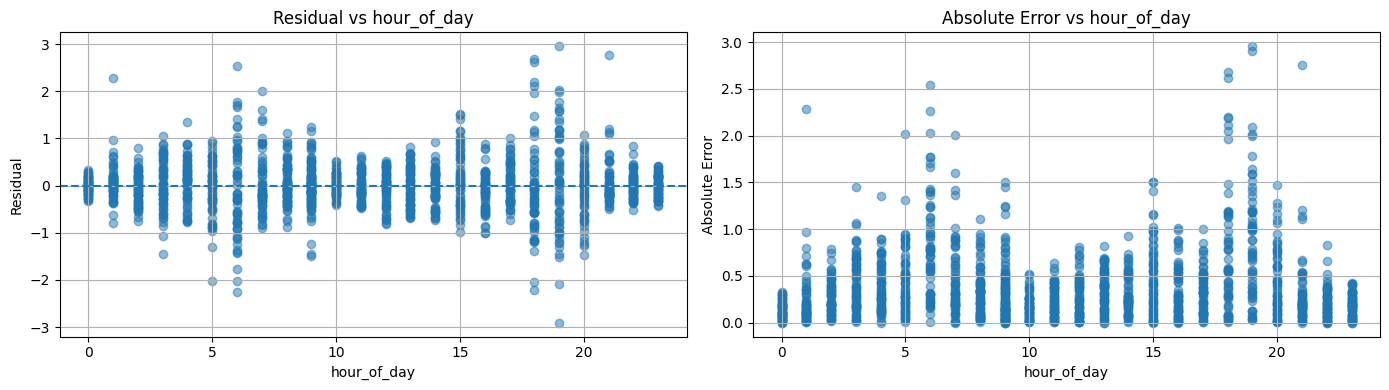

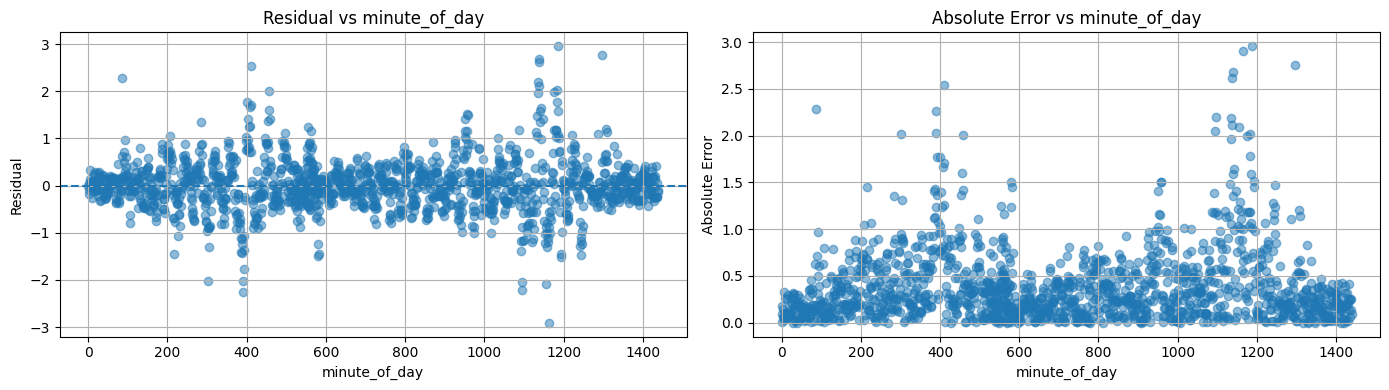

In [11]:
# Feature values versus residuals and absolute errors
for feature in FEATURES:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].scatter(
        regression_error_df[feature],
        regression_error_df["residual"],
        alpha=0.5,
    )
    axes[0].axhline(0, linestyle="--")
    axes[0].set_title(f"Residual vs {feature}")
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel("Residual")

    axes[1].scatter(
        regression_error_df[feature],
        regression_error_df["absolute_error"],
        alpha=0.5,
    )
    axes[1].set_title(f"Absolute Error vs {feature}")
    axes[1].set_xlabel(feature)
    axes[1].set_ylabel("Absolute Error")

    plt.tight_layout()
    plt.show()

In [12]:
# Quantitative feature-error relationship summary
feature_error_summary_rows = []

for feature in FEATURES:
    pearson_corr = regression_error_df[[feature, "absolute_error"]].corr(method="pearson").iloc[0, 1]
    spearman_corr = regression_error_df[[feature, "absolute_error"]].corr(method="spearman").iloc[0, 1]

    feature_error_summary_rows.append({
        "feature": feature,
        "Pearson corr with absolute error": pearson_corr,
        "Spearman corr with absolute error": spearman_corr,
    })

feature_error_summary = pd.DataFrame(feature_error_summary_rows)
feature_error_summary["max_abs_correlation"] = feature_error_summary[
    ["Pearson corr with absolute error", "Spearman corr with absolute error"]
].abs().max(axis=1)

feature_error_summary = feature_error_summary.sort_values("max_abs_correlation", ascending=False)
display(feature_error_summary)

most_error_related_feature = feature_error_summary.iloc[0]["feature"]
print("Feature most associated with absolute error:", most_error_related_feature)

,feature,Pearson corr with absolute error,Spearman corr with absolute error,max_abs_correlation
5,plug_and_light_kw,0.184880,0.111305,0.184880
1,outdoor_air_humidity,0.103087,0.149238,0.149238
0,outdoor_air_temp,-0.008348,-0.066181,0.066181
7,minute_of_day,0.061923,0.024136,0.061923
6,hour_of_day,0.059832,0.024292,0.059832
3,hvac_kw,-0.005205,-0.046321,0.046321
4,pump_kw,-0.000027,0.024817,0.024817
2,it_power_kw,-0.004937,-0.015467,0.015467


Feature most associated with absolute error: plug_and_light_kw


## 9. Analysis of Extreme Regression Errors

The assignment asks to identify the top 5% largest absolute errors and analyze them individually.

In [13]:
extreme_error_threshold = regression_error_df["absolute_error"].quantile(0.95)

extreme_errors = (
    regression_error_df[regression_error_df["absolute_error"] >= extreme_error_threshold]
    .sort_values("absolute_error", ascending=False)
    .copy()
)

print("Top 5% absolute-error threshold:", round(extreme_error_threshold, 4))
print("Number of extreme-error observations:", len(extreme_errors))

display(extreme_errors.head(20))

Top 5% absolute-error threshold: 1.1262
Number of extreme-error observations: 75


,outdoor_air_temp,outdoor_air_humidity,it_power_kw,hvac_kw,pump_kw,plug_and_light_kw,hour_of_day,minute_of_day,y_true,y_pred,residual,absolute_error
662,78.4,48.1,891.06,8.91,11.22,7.06,19,1187,18.47,15.514090,2.955910,2.955910
639,78.5,48.3,885.09,8.34,10.82,7.11,19,1164,13.47,16.377149,-2.907149,2.907149
772,82.6,44.7,905.83,8.92,11.12,5.86,21,1297,17.47,14.711394,2.758606,2.758606
614,79.0,48.7,881.18,9.29,11.42,6.59,18,1139,18.77,16.088352,2.681648,2.681648
612,78.8,48.6,880.63,8.49,10.92,6.60,18,1137,18.87,16.250944,2.619056,2.619056
1325,64.6,82.8,926.25,9.52,11.62,2.44,6,410,13.97,11.432946,2.537054,2.537054
1001,77.1,49.6,917.83,8.67,11.62,2.46,1,86,18.97,16.683620,2.286380,2.286380
1306,64.8,84.1,925.57,8.19,11.12,2.41,6,391,10.47,12.728291,-2.258291,2.258291
571,79.0,49.7,890.73,8.89,11.32,6.66,18,1096,11.27,13.474152,-2.204152,2.204152
610,78.9,48.6,880.34,9.06,11.52,6.58,18,1135,18.57,16.382653,2.187347,2.187347


In [14]:
# Compare extreme-error observations with non-extreme observations
non_extreme_errors = regression_error_df[regression_error_df["absolute_error"] < extreme_error_threshold]

comparison_rows = []

for feature in FEATURES + ["y_true", "y_pred", "absolute_error"]:
    comparison_rows.append({
        "variable": feature,
        "mean_non_extreme": non_extreme_errors[feature].mean(),
        "mean_extreme": extreme_errors[feature].mean(),
        "difference_extreme_minus_non_extreme": extreme_errors[feature].mean() - non_extreme_errors[feature].mean(),
    })

extreme_comparison = pd.DataFrame(comparison_rows)
display(extreme_comparison)

,variable,mean_non_extreme,mean_extreme,difference_extreme_minus_non_extreme
0,outdoor_air_temp,71.264070,73.128000,1.863930
1,outdoor_air_humidity,61.226667,61.877333,0.650667
2,it_power_kw,904.771361,903.414133,-1.357228
3,hvac_kw,8.840056,8.991067,0.151011
4,pump_kw,11.502260,11.535600,0.033340
5,plug_and_light_kw,3.841011,5.195333,1.354323
6,hour_of_day,11.266667,13.733333,2.466667
7,minute_of_day,705.208421,859.040000,153.831579
8,y_true,12.133930,14.307333,2.173404
9,y_pred,12.142117,14.008928,1.866810


In [15]:
print("Extreme error discussion:")
print("- Extreme errors may come from rare operating conditions, unusual weather/power combinations, or limitations of the selected model.")
print("- If extreme-error rows have feature values far from the non-extreme mean, this suggests rare or exceptional cases.")
print("- If extreme-error rows look normal but still have high error, this may suggest missing explanatory variables or model limitations.")
print("- Because the dataset is sensor-based, some extreme errors may also reflect measurement noise, timing mismatch between sensors, or hidden operational events that are not included as features.")

Extreme error discussion:
- Extreme errors may come from rare operating conditions, unusual weather/power combinations, or limitations of the selected model.
- If extreme-error rows have feature values far from the non-extreme mean, this suggests rare or exceptional cases.
- If extreme-error rows look normal but still have high error, this may suggest missing explanatory variables or model limitations.
- Because the dataset is sensor-based, some extreme errors may also reflect measurement noise, timing mismatch between sensors, or hidden operational events that are not included as features.


## 10. Statistical Properties of Regression Errors

In [16]:
residuals = regression_error_df["residual"]

error_statistics = pd.DataFrame([
    {
        "MAE": mean_absolute_error(regression_error_df["y_true"], regression_error_df["y_pred"]),
        "Residual mean": residuals.mean(),
        "Residual standard deviation": residuals.std(),
        "Residual skewness": residuals.skew(),
        "Residual kurtosis": residuals.kurt(),
    }
])

display(error_statistics)

skewness_value = residuals.skew()
kurtosis_value = residuals.kurt()

print("Statistical interpretation:")
if abs(skewness_value) < 0.5:
    print("- Residual skewness is relatively small, so there is no strong asymmetry in the residual distribution.")
elif skewness_value > 0:
    print("- Residuals are right-skewed, meaning some under-prediction errors are relatively large.")
else:
    print("- Residuals are left-skewed, meaning some over-prediction errors are relatively large.")

if kurtosis_value > 1:
    print("- Positive kurtosis suggests heavier tails, which may indicate instability or rare large errors.")
else:
    print("- Kurtosis does not suggest very heavy tails in this diagnostic.")

,MAE,Residual mean,Residual standard deviation,Residual skewness,Residual kurtosis
0,0.382418,0.007142,0.545045,0.424446,4.060598


Statistical interpretation:
- Residual skewness is relatively small, so there is no strong asymmetry in the residual distribution.
- Positive kurtosis suggests heavier tails, which may indicate instability or rare large errors.


## 11. Regression Modeling Reflection

Key points to discuss after reviewing the results:

- Linear Regression is useful as a baseline, but it may fail if the relationship between weather, IT power, time and cooling power is non-linear.
- Tree-based models can capture threshold behavior, such as cooling demand increasing sharply beyond certain load or temperature ranges.
- Random Forest often improves stability by averaging many trees, but it is less interpretable than Linear Regression.
- Large residuals should be treated as valuable diagnostic cases because they may reveal missing features, unusual operations, or sensor timing issues.
- A preferred model should be selected not only by RMSE, but also by how its errors behave across features and operational regions.

# Part B — Classification Error Analysis

## 12. Classification Models

The classification target is `high_cooling_load`.

The models compared are:

1. **Logistic Regression** — linear probabilistic baseline.
2. **Decision Tree Classifier** — non-linear interpretable model.
3. **Random Forest Classifier** — ensemble classifier.

All models are evaluated using stratified 5-fold cross-validation.

In [17]:
classification_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

classification_models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("preprocess", classification_preprocessor),
            ("model", LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE,
            )),
        ]
    ),
    "Decision Tree Classifier": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", DecisionTreeClassifier(
                max_depth=6,
                min_samples_leaf=10,
                random_state=RANDOM_STATE,
            )),
        ]
    ),
    "Random Forest Classifier": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=5,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )),
        ]
    ),
}

classification_predictions = {}
classification_probabilities = {}
classification_metric_rows = []

for model_name, model in classification_models.items():
    y_pred = cross_val_predict(
        model,
        X,
        y_cls,
        cv=classification_cv,
        n_jobs=-1,
        method="predict",
    )

    y_prob = cross_val_predict(
        model,
        X,
        y_cls,
        cv=classification_cv,
        n_jobs=-1,
        method="predict_proba",
    )[:, 1]

    classification_predictions[model_name] = y_pred
    classification_probabilities[model_name] = y_prob

    classification_metric_rows.append({
        "model": model_name,
        "Accuracy": accuracy_score(y_cls, y_pred),
        "Precision": precision_score(y_cls, y_pred, zero_division=0),
        "Recall": recall_score(y_cls, y_pred, zero_division=0),
        "F1": f1_score(y_cls, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_cls, y_pred),
        "AUC_ROC": roc_auc_score(y_cls, y_prob),
    })

classification_results = pd.DataFrame(classification_metric_rows).sort_values("F1", ascending=False)
display(classification_results)

best_classification_model_name = classification_results.iloc[0]["model"]
best_classification_predictions = classification_predictions[best_classification_model_name]
best_classification_probabilities = classification_probabilities[best_classification_model_name]

print("Best classification model by F1:", best_classification_model_name)

,model,Accuracy,Precision,Recall,F1,MCC,AUC_ROC
2,Random Forest Classifier,0.965333,0.982353,0.878947,0.927778,0.907486,0.994398
1,Decision Tree Classifier,0.956000,0.951149,0.871053,0.909341,0.881850,0.978217
0,Logistic Regression,0.918000,0.900312,0.760526,0.824536,0.776204,0.936915


Best classification model by F1: Random Forest Classifier


## 13. Confusion Matrix Analysis

The confusion matrix shows how many observations were correctly and incorrectly classified.

For the positive class:

- **TP**: truly high cooling load and predicted high cooling load.
- **FP**: not high cooling load but predicted high cooling load.
- **FN**: high cooling load but predicted not high cooling load.
- **TN**: not high cooling load and predicted not high cooling load.

,Predicted non-high cooling,Predicted high cooling
Actual non-high cooling,1114,6
Actual high cooling,46,334


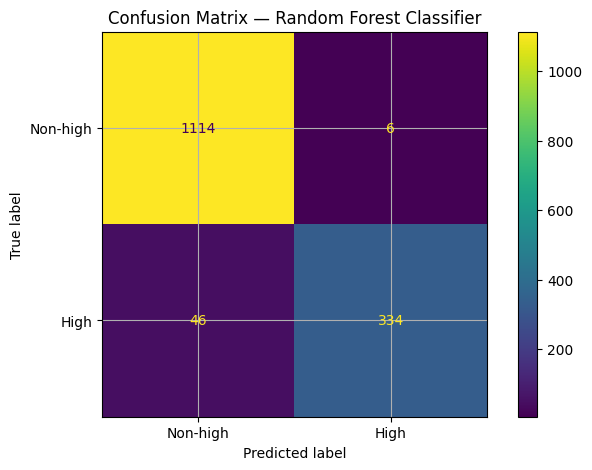

TN: 1114
FP: 6
FN: 46
TP: 334


In [18]:
confusion = confusion_matrix(y_cls, best_classification_predictions, labels=[0, 1])
confusion_df = pd.DataFrame(
    confusion,
    index=["Actual non-high cooling", "Actual high cooling"],
    columns=["Predicted non-high cooling", "Predicted high cooling"],
)

display(confusion_df)

ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=["Non-high", "High"],
).plot(values_format="d")
plt.title(f"Confusion Matrix — {best_classification_model_name}")
plt.show()

TN, FP, FN, TP = confusion.ravel()

print("TN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)

In [19]:
print("Confusion matrix interpretation:")
print("- False Positives mean the model predicts high cooling load when the real load is not in the top quartile.")
print("- False Negatives mean the model misses a truly high cooling-load situation.")
print("- In this context, False Negatives are usually more critical because missing high cooling demand may harm capacity planning, energy management, or operational readiness.")
print("- False Positives are also relevant because they may cause unnecessary operational attention, but they are generally less risky than missing a high-load condition.")

Confusion matrix interpretation:
- False Positives mean the model predicts high cooling load when the real load is not in the top quartile.
- False Negatives mean the model misses a truly high cooling-load situation.
- In this context, False Negatives are usually more critical because missing high cooling demand may harm capacity planning, energy management, or operational readiness.
- False Positives are also relevant because they may cause unnecessary operational attention, but they are generally less risky than missing a high-load condition.


## 14. Probability-Based Analysis

This section compares predicted probabilities for correct and incorrect classifications.

A high-confidence error is especially important because the model is not only wrong, but also confident in the wrong decision.

In [20]:
classification_error_df = X.copy()
classification_error_df["y_true"] = y_cls.values
classification_error_df["y_pred"] = best_classification_predictions
classification_error_df["prob_high_cooling"] = best_classification_probabilities
classification_error_df["is_correct"] = classification_error_df["y_true"] == classification_error_df["y_pred"]

classification_error_df["error_type"] = np.select(
    [
        (classification_error_df["y_true"] == 0) & (classification_error_df["y_pred"] == 0),
        (classification_error_df["y_true"] == 0) & (classification_error_df["y_pred"] == 1),
        (classification_error_df["y_true"] == 1) & (classification_error_df["y_pred"] == 0),
        (classification_error_df["y_true"] == 1) & (classification_error_df["y_pred"] == 1),
    ],
    ["TN", "FP", "FN", "TP"],
    default="Unknown",
)

classification_error_df["confidence"] = np.maximum(
    classification_error_df["prob_high_cooling"],
    1 - classification_error_df["prob_high_cooling"],
)

classification_error_df.head()

,outdoor_air_temp,outdoor_air_humidity,it_power_kw,hvac_kw,pump_kw,plug_and_light_kw,hour_of_day,minute_of_day,y_true,y_pred,prob_high_cooling,is_correct,error_type,confidence
0,67.4,63.9,887.73,9.06,11.52,2.46,8,525,0,0,0.001296,True,TN,0.998704
1,67.4,63.9,885.44,9.44,11.22,2.46,8,526,0,0,0.003106,True,TN,0.996894
2,67.3,63.9,885.08,9.34,11.22,2.44,8,527,0,0,0.000000,True,TN,1.000000
3,67.1,63.9,887.15,10.06,11.72,2.46,8,528,0,0,0.009225,True,TN,0.990775
4,67.0,63.9,885.13,10.01,11.72,2.44,8,529,0,0,0.007571,True,TN,0.992429


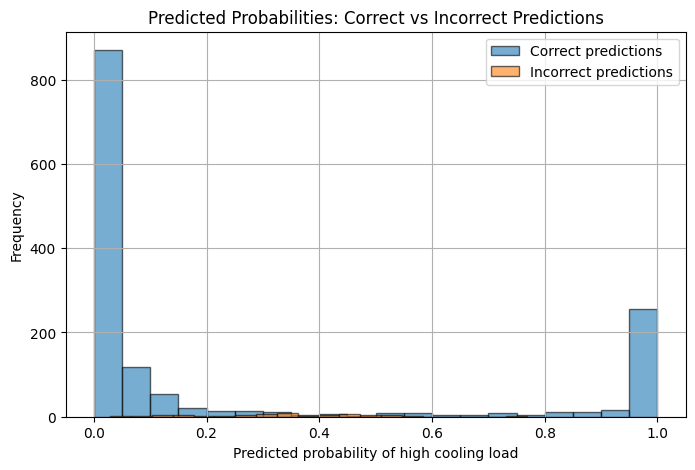

,count,mean,std,min,25%,50%,75%,max
is_correct,,,,,,,,
False,52.0,0.341864,0.154477,0.029496,0.253194,0.339692,0.449685,0.767775
True,1448.0,0.246939,0.387737,0.000000,0.004895,0.024347,0.287994,1.000000


In [21]:
# Compare probability distributions for correct and incorrect predictions
correct_probs = classification_error_df.loc[classification_error_df["is_correct"], "prob_high_cooling"]
incorrect_probs = classification_error_df.loc[~classification_error_df["is_correct"], "prob_high_cooling"]

plt.figure(figsize=(8, 5))
plt.hist(correct_probs, bins=20, alpha=0.6, label="Correct predictions", edgecolor="black")
plt.hist(incorrect_probs, bins=20, alpha=0.6, label="Incorrect predictions", edgecolor="black")
plt.title("Predicted Probabilities: Correct vs Incorrect Predictions")
plt.xlabel("Predicted probability of high cooling load")
plt.ylabel("Frequency")
plt.legend()
plt.show()

probability_summary = classification_error_df.groupby("is_correct")["prob_high_cooling"].describe()
display(probability_summary)

In [22]:
# High-confidence errors
high_confidence_errors = classification_error_df[
    (~classification_error_df["is_correct"]) &
    (classification_error_df["confidence"] >= 0.80)
].sort_values("confidence", ascending=False)

print("Number of high-confidence errors:", len(high_confidence_errors))
display(high_confidence_errors.head(20))

Number of high-confidence errors: 10


,outdoor_air_temp,outdoor_air_humidity,it_power_kw,hvac_kw,pump_kw,plug_and_light_kw,hour_of_day,minute_of_day,y_true,y_pred,prob_high_cooling,is_correct,error_type,confidence
702,79.8,45.7,914.25,8.84,10.82,6.68,20,1227,1,0,0.029496,False,FN,0.970504
701,79.7,45.7,912.20,8.74,10.92,6.68,20,1226,1,0,0.029930,False,FN,0.970070
1315,65.0,84.6,927.61,8.32,11.03,2.44,6,400,1,0,0.078887,False,FN,0.921113
703,79.9,45.8,914.22,9.41,11.72,7.12,20,1228,1,0,0.086070,False,FN,0.913930
426,73.3,57.0,904.27,8.99,11.32,7.86,15,951,1,0,0.104576,False,FN,0.895424
432,73.3,57.8,902.23,9.39,11.82,8.36,15,957,1,0,0.120690,False,FN,0.879310
704,80.0,46.0,914.67,9.52,11.62,7.18,20,1229,1,0,0.131341,False,FN,0.868659
705,80.1,46.0,909.05,9.84,11.62,7.13,20,1230,1,0,0.150386,False,FN,0.849614
1323,64.7,83.3,926.97,9.72,12.02,2.44,6,408,1,0,0.152418,False,FN,0.847582
1316,65.1,84.6,923.20,7.79,11.72,2.44,6,401,1,0,0.155762,False,FN,0.844238


## 15. Classification Error as a Function of Features

This analysis compares feature distributions for correct and incorrect predictions.  
It helps identify operational regions where misclassification is more likely.

In [23]:
# Error rate by feature bins
feature_bin_error_rows = []

for feature in FEATURES:
    try:
        bins = pd.qcut(classification_error_df[feature], q=4, duplicates="drop")
    except ValueError:
        continue

    temporary_df = classification_error_df.copy()
    temporary_df["feature_bin"] = bins

    grouped = temporary_df.groupby("feature_bin").agg(
        observations=("is_correct", "size"),
        error_rate=("is_correct", lambda s: 1 - s.mean()),
        mean_probability=("prob_high_cooling", "mean"),
    ).reset_index()

    grouped["feature"] = feature
    feature_bin_error_rows.append(grouped)

feature_bin_error_summary = pd.concat(feature_bin_error_rows, ignore_index=True)
display(feature_bin_error_summary)

,feature_bin,observations,error_rate,mean_probability,feature
0,"(61.199000000000005, 64.275]",375,0.018667,0.024749,outdoor_air_temp
1,"(64.275, 72.5]",376,0.058511,0.057282,outdoor_air_temp
2,"(72.5, 78.6]",389,0.038560,0.300561,outdoor_air_temp
3,"(78.6, 82.7]",360,0.022222,0.632241,outdoor_air_temp
4,"(43.699000000000005, 47.9]",380,0.018421,0.555834,outdoor_air_humidity
5,"(47.9, 57.35]",370,0.029730,0.339717,outdoor_air_humidity
6,"(57.35, 80.5]",376,0.021277,0.036822,outdoor_air_humidity
7,"(80.5, 85.1]",374,0.069519,0.065740,outdoor_air_humidity
8,"(861.3290000000001, 883.772]",375,0.010667,0.062255,it_power_kw
9,"(883.772, 912.085]",375,0.034667,0.155632,it_power_kw


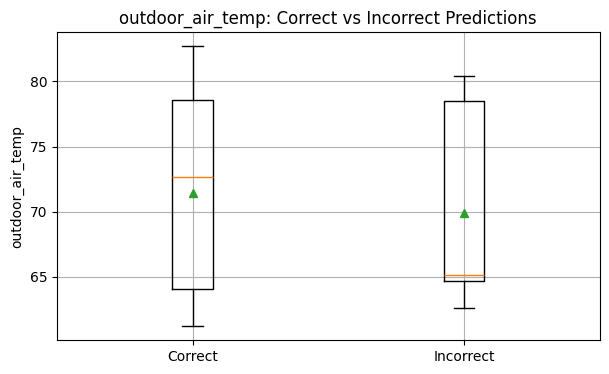

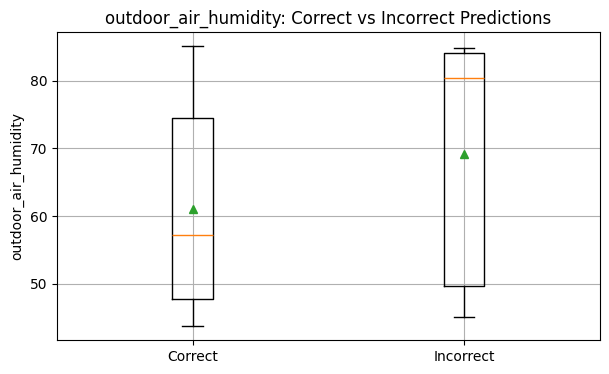

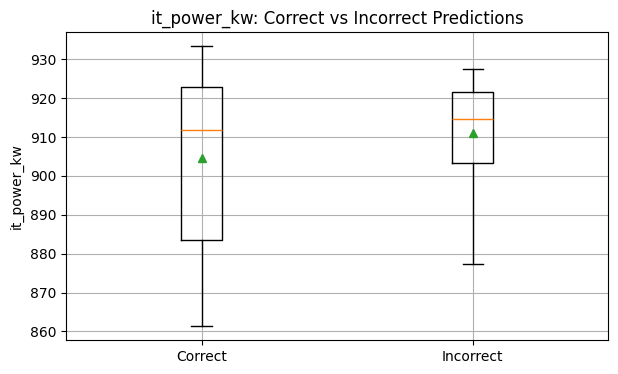

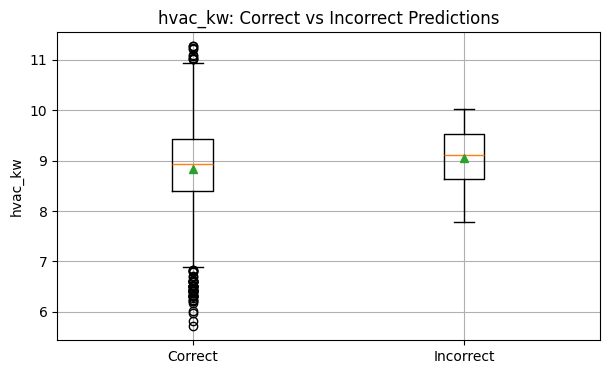

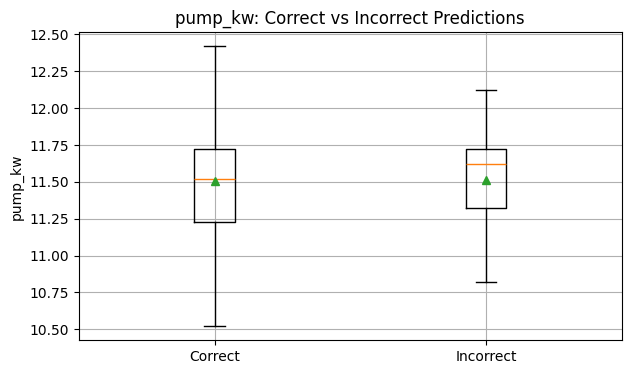

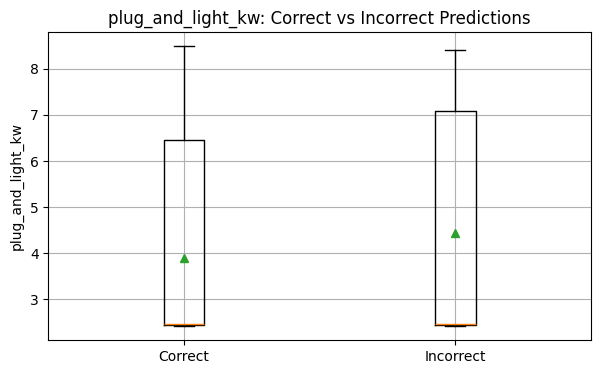

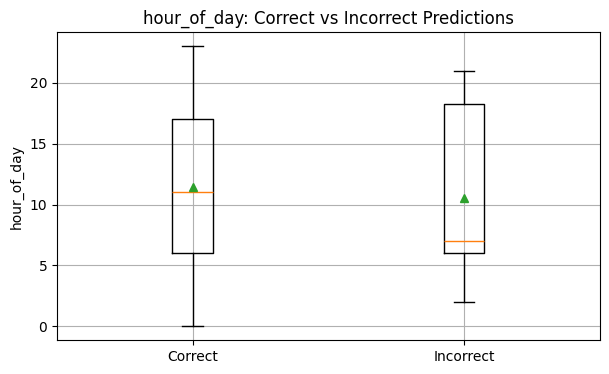

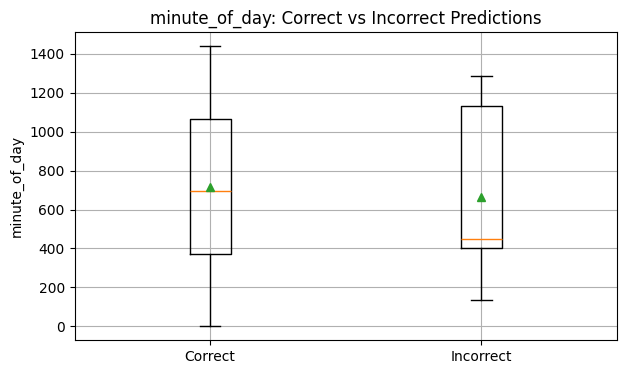

In [24]:
# Visual comparison: correct vs incorrect by feature
for feature in FEATURES:
    data_to_plot = [
        classification_error_df.loc[classification_error_df["is_correct"], feature].dropna(),
        classification_error_df.loc[~classification_error_df["is_correct"], feature].dropna(),
    ]

    plt.figure(figsize=(7, 4))
    plt.boxplot(data_to_plot, labels=["Correct", "Incorrect"], showmeans=True)
    plt.title(f"{feature}: Correct vs Incorrect Predictions")
    plt.ylabel(feature)
    plt.show()

In [25]:
print("Classification feature-error discussion:")
print("- Bins with higher error rate indicate operational regions where the classifier is less reliable.")
print("- If errors concentrate at high temperature, high IT power, or particular hours, this may indicate feature-dependent failure patterns.")
print("- If errors are spread evenly across bins, the limitations may be more related to model assumptions or the way the target was formulated.")

Classification feature-error discussion:
- Bins with higher error rate indicate operational regions where the classifier is less reliable.
- If errors concentrate at high temperature, high IT power, or particular hours, this may indicate feature-dependent failure patterns.
- If errors are spread evenly across bins, the limitations may be more related to model assumptions or the way the target was formulated.


## 16. Threshold Sensitivity Analysis

The default classification threshold is often 0.5, but operational decisions may require a different threshold.

This section evaluates thresholds from 0.1 to 0.9 and computes:

- Precision
- Recall
- F1-score
- Matthews Correlation Coefficient (MCC)

It also computes ROC-AUC and plots the ROC curve.

In [26]:
threshold_rows = []

for threshold in np.arange(0.1, 1.0, 0.1):
    threshold_predictions = (best_classification_probabilities >= threshold).astype(int)

    threshold_rows.append({
        "threshold": round(float(threshold), 1),
        "precision": precision_score(y_cls, threshold_predictions, zero_division=0),
        "recall": recall_score(y_cls, threshold_predictions, zero_division=0),
        "f1": f1_score(y_cls, threshold_predictions, zero_division=0),
        "mcc": matthews_corrcoef(y_cls, threshold_predictions),
        "false_positives": confusion_matrix(y_cls, threshold_predictions, labels=[0, 1]).ravel()[1],
        "false_negatives": confusion_matrix(y_cls, threshold_predictions, labels=[0, 1]).ravel()[2],
    })

threshold_results = pd.DataFrame(threshold_rows)
display(threshold_results)

best_threshold_by_f1 = threshold_results.sort_values("f1", ascending=False).iloc[0]["threshold"]
print("Best threshold by F1:", best_threshold_by_f1)

,threshold,precision,recall,f1,mcc,false_positives,false_negatives
0,0.1,0.738703,0.989474,0.845894,0.799807,133,4
1,0.2,0.862471,0.973684,0.914710,0.886420,59,10
2,0.3,0.921320,0.955263,0.937984,0.916703,31,17
3,0.4,0.958791,0.918421,0.938172,0.918170,15,31
4,0.5,0.982353,0.878947,0.927778,0.907486,6,46
5,0.6,0.996855,0.834211,0.908309,0.886725,1,63
6,0.7,0.996753,0.807895,0.892442,0.868884,1,73
7,0.8,1.000000,0.773684,0.872404,0.847651,0,86
8,0.9,1.000000,0.713158,0.832565,0.806169,0,109


Best threshold by F1: 0.4


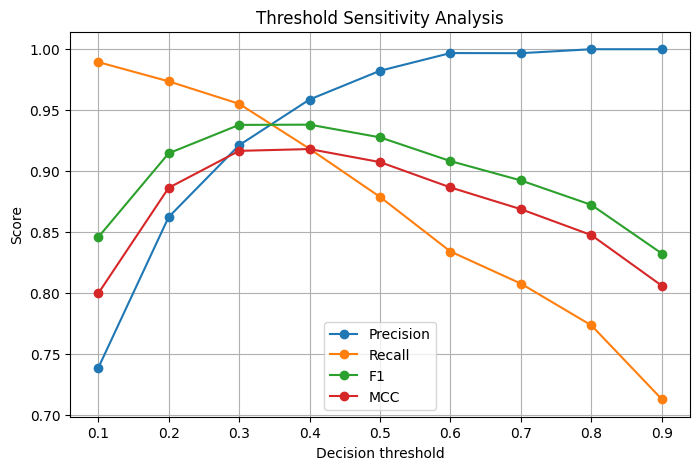

In [27]:
# Plot threshold sensitivity
plt.figure(figsize=(8, 5))
plt.plot(threshold_results["threshold"], threshold_results["precision"], marker="o", label="Precision")
plt.plot(threshold_results["threshold"], threshold_results["recall"], marker="o", label="Recall")
plt.plot(threshold_results["threshold"], threshold_results["f1"], marker="o", label="F1")
plt.plot(threshold_results["threshold"], threshold_results["mcc"], marker="o", label="MCC")
plt.title("Threshold Sensitivity Analysis")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

,beta,F_beta
0,0.25,0.956319
1,0.50,0.950436
2,1.00,0.938172
3,2.00,0.926221
4,4.00,0.920701


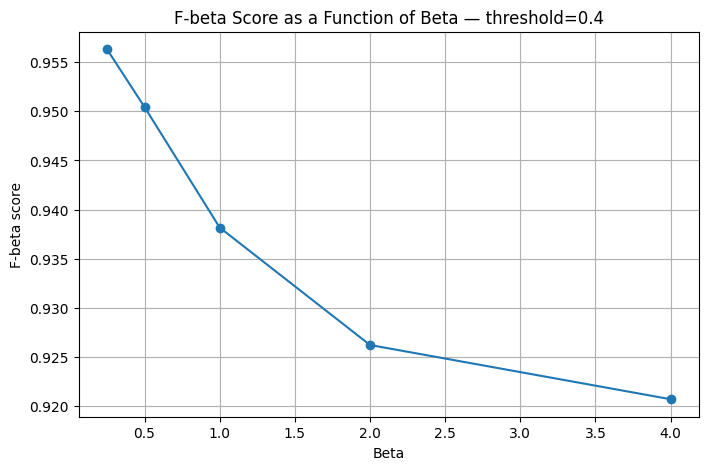

In [28]:
# F-beta score as a function of beta, using the threshold with best F1
selected_threshold = float(best_threshold_by_f1)
selected_predictions = (best_classification_probabilities >= selected_threshold).astype(int)

beta_values = np.array([0.25, 0.5, 1.0, 2.0, 4.0])
fbeta_values = [
    fbeta_score(y_cls, selected_predictions, beta=beta, zero_division=0)
    for beta in beta_values
]

fbeta_table = pd.DataFrame({
    "beta": beta_values,
    "F_beta": fbeta_values,
})

display(fbeta_table)

plt.figure(figsize=(8, 5))
plt.plot(fbeta_table["beta"], fbeta_table["F_beta"], marker="o")
plt.title(f"F-beta Score as a Function of Beta — threshold={selected_threshold}")
plt.xlabel("Beta")
plt.ylabel("F-beta score")
plt.show()

AUC-ROC: 0.9944


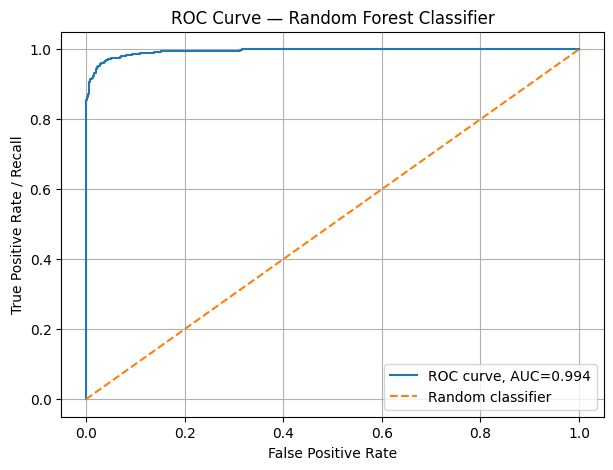

In [29]:
# ROC-AUC and ROC curve
auc_value = roc_auc_score(y_cls, best_classification_probabilities)
fpr, tpr, roc_thresholds = roc_curve(y_cls, best_classification_probabilities)

print("AUC-ROC:", round(auc_value, 4))

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC curve, AUC={auc_value:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.title(f"ROC Curve — {best_classification_model_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.legend()
plt.show()

### Threshold Sensitivity Discussion

Lower thresholds usually increase recall but also increase false positives.  
Higher thresholds usually increase precision but also increase false negatives.

In this context, missing a truly high cooling-load situation may be more critical than creating an unnecessary high-load warning. Therefore, the preferred threshold should not be selected only by accuracy. It should reflect the operational cost of false negatives versus false positives.

## 17. Classification Model Discussion

The classification results should be interpreted as follows:

- **Logistic Regression** is simple and interpretable but assumes a mostly linear decision boundary.
- **Decision Tree Classifier** can capture non-linear rules and thresholds, but it can be unstable if the tree overfits.
- **Random Forest Classifier** usually improves robustness by averaging many trees, but it is less transparent.

The preferred model is selected by F1-score because the positive class, high cooling load, is operationally important and the target is not perfectly balanced.

# 18. Final Reflection

## 1. Where does the model fail most?

The regression model fails most in observations with the largest absolute residuals. These cases often correspond to unusual combinations of cooling demand, IT power, weather, or time-based behavior. The classification model fails most where the feature distributions of high and non-high cooling load overlap, especially near the decision boundary.

## 2. Are failures due to data, model, or formulation?

The failures likely come from a combination of three sources:

- **Data:** Sensor measurements may be noisy, missing, or not perfectly synchronized.
- **Model:** Linear models may miss non-linear relationships; tree models may still miss patterns when important variables are absent.
- **Formulation:** The classification target `high_cooling_load` is derived from the top quartile of `cooling_kw`. This is useful for analysis, but it is an artificial operational definition rather than a direct physical failure label.

## 3. What improvements would I propose?

Recommended improvements:

- Use a longer time period to capture weekly and seasonal behavior.
- Add lag features, rolling averages, and previous cooling-load values.
- Add more operational context such as chiller status, setpoints, occupancy, maintenance events, and equipment modes.
- Tune hyperparameters using nested cross-validation or a validation strategy that respects time order.
- Evaluate the cost of false positives and false negatives before choosing a classification threshold.

## 4. What insights did I gain?

The main insight is that model quality cannot be understood only through global metrics. Error analysis reveals where the model is reliable and where it fails. Residuals, extreme errors, confusion matrices, probability analysis, and threshold sensitivity provide a deeper understanding of the relationship between the data, the model assumptions, and the operational problem definition.

# 19. Submission Notes

Before submitting:

1. Fill in the Student ID at the top of the notebook.
2. Run the notebook from top to bottom.
3. Confirm that no cell raises an error.
4. If the notebook created `data_center_working_sample_ex2.csv`, include it if your instructor needs to rerun the notebook without the raw CSV files.
5. Push the updated notebook and README to the same GitHub repository, or submit the notebook file directly if requested.